Imports y apertura del archivo

In [112]:
import pandas as pd
import numpy as np

df = pd.read_csv("CARTERA 2023 (P1).csv")

Primera revisión

In [113]:
df.head()  

,id_cliente,periodo,sucursal,provincia,fecha_alta,edad,tipo_empleo,ingreso_declarado,antiguedad_laboral,deuda_actual,cant_productos,consumo_tarjeta_mensual,mora_historica,score_buro,cant_consultas_recientes,saldo_promedio,limite_tarjeta,cant_atrasos_12m,monto_prestamo_solicitado
0,CL202304359,2023,Córdoba Shopping,Santa Fe,03/02/2019,41,s/d,272000.0,8.9,153000.0,3,137000.0,1,595.0,3,169000.0,591000.0,1,740000.0
1,CL202302163,2023,Mendoza Sur,Mendoza,12/24/2017,37,monotributo,911000.0,NaN,164000.0,3,249000.0,0,642.0,0,201000.0,1488000.0,0,1897000.0
2,CL202304386,2023,Central,Mendoza,17/02/2016,53,s/d,264000.0,13.4,99000.0,3,149000.0,0,NaN,3,176000.0,433000.0,2,1885000.0
3,CL202305394,2023,Central,Buenos Aires,2016-01-08,43,Monotributo,NaN,8.1,196000.0,2,233000.0,Sí,584.0,1,152000.0,996000.0,0,2968000.0
4,CL202303465,2023,Central,Tucumán,06/24/2018,35,monotributo,1228000.0,6.3,141000.0,3,418000.0,No,810.0,0,671000.0,1827000.0,0,3334000.0


In [114]:
df.shape                      # dimensiones                   # primeras filas
df.info()                     # tipos y no-nulos
df.isna().sum()               # faltantes por columna
df.duplicated().sum()         # filas duplicadas
df["id_cliente"].duplicated().sum()   # ids repetidos
df["id_cliente"].str.len().value_counts()  # largo de los ids

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6840 entries, 0 to 6839
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 6840 non-null   object 
 1   periodo                    6840 non-null   int64  
 2   sucursal                   6840 non-null   object 
 3   provincia                  6840 non-null   object 
 4   fecha_alta                 6840 non-null   object 
 5   edad                       6840 non-null   int64  
 6   tipo_empleo                6840 non-null   object 
 7   ingreso_declarado          5536 non-null   float64
 8   antiguedad_laboral         5497 non-null   float64
 9   deuda_actual               6840 non-null   float64
 10  cant_productos             6840 non-null   int64  
 11  consumo_tarjeta_mensual    6840 non-null   float64
 12  mora_historica             6840 non-null   object 
 13  score_buro                 6306 non-null   float

id_cliente
11    6815
12      25
Name: count, dtype: int64

Estandarización de mora y tipo empleo

In [115]:
df_raw = df.copy()

emp = df["tipo_empleo"].str.strip().str.lower()

mapa_empleo = {
    "rd": "Relación de dependencia",
    "rel. dependencia": "Relación de dependencia",
    "relacion de dependencia": "Relación de dependencia",
    "relación de dependencia": "Relación de dependencia",
    "mt": "Monotributo",
    "monotrib.": "Monotributo",
    "monotributo": "Monotributo",
    "informal": "Informal",
    "changas": "Informal",
    "s/d": np.nan,
}
df["tipo_empleo"] = emp.map(mapa_empleo)

mora = df["mora_historica"].astype(str).str.strip().str.lower()
mapa_mora = {"no": 0, "n": 0, "0": 0,
             "si": 1, "sí": 1, "s": 1, "1": 1}
df["mora_historica"] = mora.map(mapa_mora)

df["tipo_empleo"].value_counts(dropna=False)
df["mora_historica"].value_counts(dropna=False)
df["mora_historica"].value_counts(normalize=True)

df["mora_historica"].isna().sum()
pd.crosstab(df_raw["tipo_empleo"], df["tipo_empleo"].fillna("NaN"))

tipo_empleo,Informal,Monotributo,NaN,Relación de dependencia
tipo_empleo,,,,
Informal,369,0,0,0
MT,0,555,0,0
Monotributo,0,507,0,0
RD,0,0,0,803
Rel. Dependencia,0,0,0,860
Relación de Dependencia,0,0,0,845
changas,325,0,0,0
informal,322,0,0,0
monotrib.,0,551,0,0


Revision de IDS

In [116]:
ids_lower = df["id_cliente"].str.lower()
ids_lower.nunique(), ids_lower.duplicated().sum()

ids_std = df["id_cliente"].str.strip().str.lower()
ids_std.nunique(), ids_std.duplicated().sum()

(6800, np.int64(40))

In [117]:
dup = df[ids_std.duplicated(keep=False)].assign(id_std=ids_std).sort_values("id_std")
dup.head(10)

cols = [c for c in df.columns if c != "id_cliente"]
(dup.groupby("id_std")[cols].nunique(dropna=False) > 1).sum()

periodo                      0
sucursal                     0
provincia                    0
fecha_alta                   0
edad                         0
tipo_empleo                  0
ingreso_declarado            0
antiguedad_laboral           0
deuda_actual                 0
cant_productos               0
consumo_tarjeta_mensual      0
mora_historica               0
score_buro                   0
cant_consultas_recientes     0
saldo_promedio               0
limite_tarjeta               0
cant_atrasos_12m             0
monto_prestamo_solicitado    0
dtype: int64

Clave: encontramos que los ids de len = 12 tenían espacios. Ademas los que estaban en minusculas también eran un problema. Estos ids no eran únicos; los registros estaban exacamente duplicados en todas las entradas. Quitamos duplicados

In [118]:
df["id_cliente"] = df["id_cliente"].str.strip().str.lower()

df = df.drop_duplicates(subset="id_cliente", keep="first").reset_index(drop=True)

df.shape                         
df["id_cliente"].is_unique        

True

Fechas:

In [119]:
s = df["fecha_alta"].str.strip()
es_iso = s.str.match(r"^\d{4}-\d{2}-\d{2}$")

df["anio_alta"] = np.where(es_iso, s.str[:4], s.str[-4:]).astype(int)

p = s.str.extract(r"^(\d{1,2})/(\d{1,2})/\d{4}$").astype(float)   # NaN si es ISO
a, b = p[0], p[1]
formato = np.select([es_iso, a > 12, b > 12, a == b],
                    ["ISO", "DD/MM", "MM/DD", "igual"], default="ambiguo")
pd.Series(formato).value_counts()

df["fecha_alta_std"] = pd.NaT
f_iso = formato == "ISO"
f_dm  = np.isin(formato, ["DD/MM", "igual"])
f_md  = formato == "MM/DD"
df.loc[f_iso, "fecha_alta_std"] = pd.to_datetime(s[f_iso], format="%Y-%m-%d")
df.loc[f_dm,  "fecha_alta_std"] = pd.to_datetime(s[f_dm],  format="%d/%m/%Y")
df.loc[f_md,  "fecha_alta_std"] = pd.to_datetime(s[f_md],  format="%m/%d/%Y")
df["fecha_alta_std"] = pd.to_datetime(df["fecha_alta_std"])

df["fecha_alta_std"].isna().sum()        # 1912
df["anio_alta"].value_counts().sort_index()

anio_alta
2016    1152
2017    1147
2018    1156
2019    1121
2020    1121
2021    1103
Name: count, dtype: int64

Problema y decisión de diseño: hay ciertas fechas que no se puede distinguir si son dd/mm/aaaa o mm/dd/aaaa (Ej: 09/11/aaaa). Por esta razón se decidió crear dos columnas nuevas: anio_alta, que contiene los anios de alta de cada cliente, que son distnguibles sin inconvenientes, donde no hay nulos, y por otro lado fecha_alta_std, que contiene las fechas que podemos identificar inequivoacmente sin importar su formato (si algun campo es mayor a 12 indefectriblemente se trata del día, las que tienen formato ISO (AAAA-MM-DD) y las que dd == mm, sin importar si es dd/mm o mm/dd). Esta columna tiene como NaT todas las fechas que no se puede distinguir si estan como mm/dd/aaaa o como dd/mm/aaaa.

Análisis de consumo tarjeta

In [120]:
c = df["consumo_tarjeta_mensual"]

(c < 1000).sum()
df.groupby("sucursal")["consumo_tarjeta_mensual"].apply(lambda x: (x < 1000).mean())


sucursal
Canal Digital       0.997683
Central             0.000000
Córdoba Shopping    0.000000
La Plata            0.000000
Mendoza Sur         0.000000
Microcentro         0.000000
Palermo             0.000000
Rosario Norte       0.000000
Name: consumo_tarjeta_mensual, dtype: float64

In [121]:
cd = df["sucursal"] == "Canal Digital"
cd.sum(), (c[cd] < 1000).sum(), (c[cd] >= 1000).sum()
(c[~cd] % 1000 != 0).sum()

ratio_raw = c / df["limite_tarjeta"]
ratio_raw.groupby(cd).median()
(c.where(~cd, c * 1000) / df["limite_tarjeta"]).groupby(cd).median()

df.loc[cd, "consumo_tarjeta_mensual"] = df.loc[cd, "consumo_tarjeta_mensual"] * 1000
df["consumo_tarjeta_mensual"].describe()

count    6.800000e+03
mean     1.915904e+05
std      1.623974e+05
min      5.000000e+03
25%      8.000000e+04
50%      1.470000e+05
75%      2.520000e+05
max      1.672000e+06
Name: consumo_tarjeta_mensual, dtype: float64

Errores en antiguedad: 198 clientes parece que empezaron a trabajr antes de los 16 años. Esto probablemente debería ser un error, ya que 16 es la edad minima legal para empezar a trabajar. Se decidió no tocar la variable directamente, sino agregar flags donde este dato (edad - anitguedad) diera un inconsistencia. 

In [122]:
df["inicio_laboral_implicito"] = df["edad"] - df["antiguedad_laboral"]

df["flag_antig_inconsistente"] = df["inicio_laboral_implicito"] < 16

df["flag_antig_inconsistente"].sum()             
df["flag_antig_inconsistente"].mean()            
df["flag_antig_inconsistente"].sum() / df["antiguedad_laboral"].notna().sum() 
df.loc[df["flag_antig_inconsistente"], ["edad", "antiguedad_laboral", "inicio_laboral_implicito"]].head()

,edad,antiguedad_laboral,inicio_laboral_implicito
56,18,3.3,14.7
112,23,7.1,15.9
194,18,3.9,14.1
229,18,3.7,14.3
231,18,2.5,15.5


Análisis de ingreso declarado

Spearman ingreso-límite: 0.91


,ratio_limite_ingreso,ratio_prestamo_ingreso
count,5501.000,5501.000
mean,1.488,4.691
std,0.415,1.886
min,0.084,0.177
1%,0.808,1.532
50%,1.490,4.649
99%,2.184,7.940
max,2.201,7.997


ratio_limite_ingreso
(0.0, 0.1]        1
(0.1, 0.2]       16
(0.2, 0.3]        5
(0.3, 0.5]        0
(0.5, 0.75]       0
(0.75, 1.0]     829
(1.0, 1.5]     1940
(1.5, 2.0]     1938
(2.0, 2.3]      772
Name: count, dtype: int64

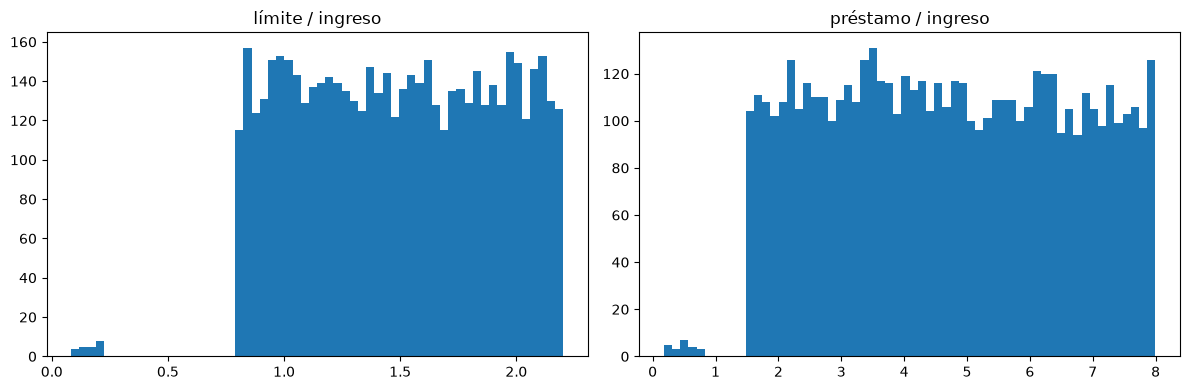

In [123]:
import numpy as np
import matplotlib.pyplot as plt

df["ratio_limite_ingreso"]   = df["limite_tarjeta"] / df["ingreso_declarado"]
df["ratio_prestamo_ingreso"] = df["monto_prestamo_solicitado"] / df["ingreso_declarado"]

print("Spearman ingreso-límite:",
      round(df[["ingreso_declarado", "limite_tarjeta"]].corr(method="spearman").iloc[0, 1], 2))

display(df[["ratio_limite_ingreso", "ratio_prestamo_ingreso"]]
        .describe(percentiles=[.01, .5, .99]).round(3))

bins = [0, 0.1, 0.2, 0.3, 0.5, 0.75, 1, 1.5, 2, 2.3]
display(pd.cut(df["ratio_limite_ingreso"], bins).value_counts().sort_index())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df["ratio_limite_ingreso"].dropna(), bins=60);   ax[0].set_title("límite / ingreso")
ax[1].hist(df["ratio_prestamo_ingreso"].dropna(), bins=60); ax[1].set_title("préstamo / ingreso")
plt.tight_layout(); plt.show()

In [124]:
df["flag_ingreso_inconsistente"] = df["ratio_limite_ingreso"] < 0.5
f = df["flag_ingreso_inconsistente"]

print("Flagueados:", f.sum(),
      "| sobre los que tienen ingreso:", round(f.sum() / df["ingreso_declarado"].notna().sum(), 4))

display(df.loc[f, ["edad", "tipo_empleo", "ingreso_declarado", "limite_tarjeta",
                   "monto_prestamo_solicitado", "ratio_limite_ingreso",
                   "ratio_prestamo_ingreso"]]
          .sort_values("ingreso_declarado", ascending=False))

display(pd.crosstab(df["tipo_empleo"].fillna("s/d"), f))

Flagueados: 22 | sobre los que tienen ingreso: 0.004


,edad,tipo_empleo,ingreso_declarado,limite_tarjeta,monto_prestamo_solicitado,ratio_limite_ingreso,ratio_prestamo_ingreso
5589,49,Relación de dependencia,22160000.0,3467000.0,3927000.0,0.156453,0.177211
5884,42,Relación de dependencia,19450000.0,2448000.0,9518000.0,0.125861,0.489357
4023,34,Relación de dependencia,16960000.0,3285000.0,4297000.0,0.193691,0.253361
4638,44,Relación de dependencia,16770000.0,2645000.0,8332000.0,0.157722,0.496840
1641,29,Relación de dependencia,13610000.0,1381000.0,5454000.0,0.101470,0.400735
3013,36,Relación de dependencia,12050000.0,2484000.0,2646000.0,0.206141,0.219585
5032,40,Relación de dependencia,11680000.0,1922000.0,5792000.0,0.164555,0.495890
2226,26,Relación de dependencia,9400000.0,1822000.0,1831000.0,0.193830,0.194787
4625,43,Relación de dependencia,9400000.0,2056000.0,4918000.0,0.218723,0.523191
5509,45,Monotributo,7720000.0,1550000.0,4436000.0,0.200777,0.574611


flag_ingreso_inconsistente,False,True
tipo_empleo,,
Informal,1002,4
Monotributo,2123,6
Relación de dependencia,3333,12
s/d,320,0


In [125]:
ratio_lim_10 = df.loc[f, "limite_tarjeta"]            / (df.loc[f, "ingreso_declarado"] / 10)
ratio_pre_10 = df.loc[f, "monto_prestamo_solicitado"] / (df.loc[f, "ingreso_declarado"] / 10)

print("límite / (ingreso/10):");    display(ratio_lim_10.describe().round(2))
print("préstamo / (ingreso/10):");  display(ratio_pre_10.describe().round(2))

print("Banda normal límite/ingreso (P1-P99, resto):",
      df.loc[~f, "ratio_limite_ingreso"].quantile([.01, .99]).round(2).tolist())
print("Banda normal préstamo/ingreso (P1-P99, resto):",
      df.loc[~f, "ratio_prestamo_ingreso"].quantile([.01, .99]).round(2).tolist())

df["ingreso_corregido"] = np.where(f, df["ingreso_declarado"] / 10, df["ingreso_declarado"])

print("Valores modificados:", (df["ingreso_corregido"] < df["ingreso_declarado"]).sum())
print("Máximo corregido:", df["ingreso_corregido"].max())

límite / (ingreso/10):


count    22.00
mean      1.60
std       0.40
min       0.84
25%       1.29
50%       1.58
75%       1.97
max       2.19
dtype: float64

préstamo / (ingreso/10):


count    22.00
mean      4.76
std       1.69
min       1.77
25%       3.99
50%       5.01
75%       5.77
max       7.60
dtype: float64

Banda normal límite/ingreso (P1-P99, resto): [0.81, 2.18]
Banda normal préstamo/ingreso (P1-P99, resto): [1.56, 7.94]
Valores modificados: 22
Máximo corregido: 3881000.0


El cociente limite_tarjeta / ingreso_declarado se ubica entre 0,8 y 2,2 para 5479 clientes y entre 0,08 y 0,22 para 22 clientes, sin ningún caso intermedio; lo mismo ocurre con monto_prestamo_solicitado / ingreso_declarado. Al dividir esos 22 ingresos por 10, ambos cocientes caen dentro del rango normal, lo que sugiere un error de carga (un cero de más). Se conserva ingreso_declarado sin modificar, se marcan los casos con flag_ingreso_inconsistente y se genera ingreso_corregido solo como versión alternativa para análisis de sensibilidad. Limitación: la detección usa el límite de la tarjeta como referencia, por lo que solo evalúa a los clientes con ingreso cargado.

Faltantes:

In [126]:
cols_na = ["ingreso_declarado", "antiguedad_laboral", "score_buro", "tipo_empleo"]

resumen = pd.DataFrame({"n_faltantes": df[cols_na].isna().sum(),
                        "%": (df[cols_na].isna().mean() * 100).round(2)})
display(resumen)
print("Filas con al menos un faltante:", df[cols_na].isna().any(axis=1).sum())
print("Filas sin ningún faltante:", (~df[cols_na].isna().any(axis=1)).sum())

,n_faltantes,%
ingreso_declarado,1299,19.10
antiguedad_laboral,1332,19.59
score_buro,530,7.79
tipo_empleo,320,4.71


Filas con al menos un faltante: 2877
Filas sin ningún faltante: 3923


Matriz de correlacion para tratar de entender mejor como poder imputar los faltantes

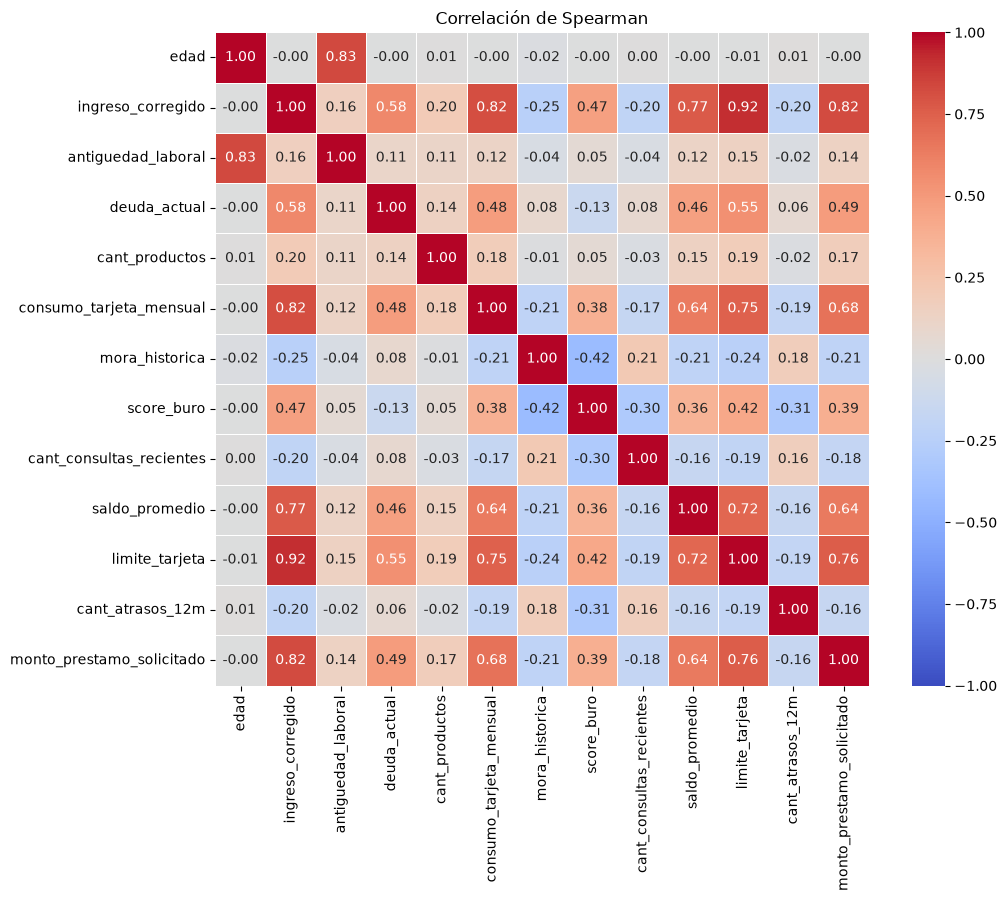

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt

vars_corr = ["edad", "ingreso_corregido", "antiguedad_laboral", "deuda_actual", "cant_productos",
             "consumo_tarjeta_mensual", "mora_historica", "score_buro", "cant_consultas_recientes",
             "saldo_promedio", "limite_tarjeta", "cant_atrasos_12m", "monto_prestamo_solicitado"]

corr = df[vars_corr].corr(method="spearman")

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title("Correlación de Spearman"); plt.tight_layout(); plt.show()

In [128]:
for v in ["ingreso_corregido", "antiguedad_laboral", "score_buro"]:
    top = corr[v].drop(v).sort_values(key=abs, ascending=False).head(5)
    print(f"\n{v}:"); display(top.round(2))


ingreso_corregido:


limite_tarjeta               0.92
monto_prestamo_solicitado    0.82
consumo_tarjeta_mensual      0.82
saldo_promedio               0.77
deuda_actual                 0.58
Name: ingreso_corregido, dtype: float64


antiguedad_laboral:


edad                         0.83
ingreso_corregido            0.16
limite_tarjeta               0.15
monto_prestamo_solicitado    0.14
consumo_tarjeta_mensual      0.12
Name: antiguedad_laboral, dtype: float64


score_buro:


ingreso_corregido            0.47
limite_tarjeta               0.42
mora_historica              -0.42
monto_prestamo_solicitado    0.39
consumo_tarjeta_mensual      0.38
Name: score_buro, dtype: float64

In [129]:
ind = df[cols_na].isna().astype(int).add_prefix("na_")
display(ind.corr().round(3))          # ¿faltan juntos?

display(df.groupby(df["tipo_empleo"].fillna("s/d"))["antiguedad_laboral"]
          .apply(lambda x: x.isna().mean() * 100).round(1))

for a, b in [("ingreso_declarado", "antiguedad_laboral"),
             ("ingreso_declarado", "score_buro"),
             ("score_buro", "tipo_empleo")]:
    obs = (df[a].isna() & df[b].isna()).sum()
    esp = df[a].isna().mean() * df[b].isna().mean() * len(df)
    print(f"{a} & {b}: observados {obs}, esperados si fueran independientes {esp:.0f}")

,na_ingreso_declarado,na_antiguedad_laboral,na_score_buro,na_tipo_empleo
na_ingreso_declarado,1.000,0.002,0.014,0.005
na_antiguedad_laboral,0.002,1.000,0.004,0.076
na_score_buro,0.014,0.004,1.000,0.003
na_tipo_empleo,0.005,0.076,0.003,1.000


tipo_empleo
Informal                   33.3
Monotributo                34.5
Relación de dependencia     4.7
s/d                        33.1
Name: antiguedad_laboral, dtype: float64

ingreso_declarado & antiguedad_laboral: observados 257, esperados si fueran independientes 254
ingreso_declarado & score_buro: observados 111, esperados si fueran independientes 101
score_buro & tipo_empleo: observados 26, esperados si fueran independientes 25


Primer imputación: ingresos. 5 pruebas: mediana global, mediana por tipo_empleo, regresión log log con 1 feature, con 2 features y con 3 features.

In [130]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_predict

pred_cols = ["limite_tarjeta", "monto_prestamo_solicitado", "consumo_tarjeta_mensual"]  # completas y > 0
obs = df["ingreso_corregido"].notna()
d = df[obs].copy()
y_real = d["ingreso_corregido"]
y_log  = np.log(y_real)

def metricas(nombre, y_hat):
    mae   = np.mean(np.abs(y_real - y_hat))
    mdape = np.median(np.abs(y_real - y_hat) / y_real) * 100
    print(f"{nombre:45s} MAE = ${mae:>9,.0f} | error mediano = {mdape:5.1f}%")

# Referencias simples
metricas("Mediana global", pd.Series(y_real.median(), index=d.index))
metricas("Mediana por tipo_empleo",
         d.groupby("tipo_empleo")["ingreso_corregido"].transform("median").fillna(y_real.median()))

# Regresión sobre logs, con validación cruzada
kf = KFold(n_splits=5, shuffle=True, random_state=0)
for k in range(1, len(pred_cols) + 1):
    X = np.log(d[pred_cols[:k]])
    log_hat = cross_val_predict(LinearRegression(), X, y_log, cv=kf)
    r2 = 1 - np.sum((y_log - log_hat) ** 2) / np.sum((y_log - y_log.mean()) ** 2)
    metricas(f"Regresión log-log con {k} predictor(es)", np.exp(log_hat))
    print(f"{'':45s} R2 (validación, en log) = {r2:.3f}")

Mediana global                                MAE = $  315,355 | error mediano =  43.8%
Mediana por tipo_empleo                       MAE = $  246,600 | error mediano =  33.9%
Regresión log-log con 1 predictor(es)         MAE = $  131,883 | error mediano =  20.9%
                                              R2 (validación, en log) = 0.854
Regresión log-log con 2 predictor(es)         MAE = $  114,803 | error mediano =  16.7%
                                              R2 (validación, en log) = 0.889
Regresión log-log con 3 predictor(es)         MAE = $  106,011 | error mediano =  15.2%
                                              R2 (validación, en log) = 0.905


Se osberva que con 3 predictoras se logra un R2 de 0.89 y un MAE de 16.6. Por esto y en comparación con las otras formas de imputación, esta alternativa es la más óptima para este caso

In [131]:
modelo = LinearRegression().fit(np.log(d[pred_cols]), y_log)
print(dict(zip(pred_cols, modelo.coef_.round(3))), "| intercepto:", round(modelo.intercept_, 3))

faltan = df["ingreso_corregido"].isna()
df["ingreso_imputado"] = df["ingreso_corregido"]
pred = np.exp(modelo.predict(np.log(df.loc[faltan, pred_cols])))
print("Imputados por debajo del piso (90.000):", (pred < 90_000).sum())
df.loc[faltan, "ingreso_imputado"] = np.maximum(pred, 90_000)      # respeta el piso
df["flag_ingreso_imputado"] = faltan

comp = pd.DataFrame({"observados": df.loc[~faltan, "ingreso_imputado"],
                     "imputados":   df.loc[faltan, "ingreso_imputado"],
                     "todos":       df["ingreso_imputado"]}).describe().round(0)
display(comp)
print("Faltantes restantes:", df["ingreso_imputado"].isna().sum())
display(df.groupby(faltan)["limite_tarjeta"].median())

{'limite_tarjeta': np.float64(0.554), 'monto_prestamo_solicitado': np.float64(0.212), 'consumo_tarjeta_mensual': np.float64(0.141)} | intercepto: 0.907
Imputados por debajo del piso (90.000): 4


,observados,imputados,todos
count,5501.0,1299.0,6800.0
mean,630412.0,647665.0,633708.0
std,431551.0,450563.0,435266.0
min,90000.0,90000.0,90000.0
25%,315000.0,333143.0,317684.0
50%,528000.0,540409.0,531000.0
75%,828000.0,845221.0,833000.0
max,3881000.0,3757409.0,3881000.0


Faltantes restantes: 0


ingreso_corregido
False    755000.0
True     757000.0
Name: limite_tarjeta, dtype: float64

Imputación score:

In [132]:
s = df["score_buro"]
print(s.describe().round(1))
print("Asimetría:", round(s.skew(), 2), "| en el máximo (850):", (s == 850).sum())

df["dti"] = df["deuda_actual"] / df["ingreso_imputado"]      # deuda sobre ingreso

cols = ["mora_historica", "cant_atrasos_12m", "cant_consultas_recientes",
        "dti", "limite_tarjeta", "ingreso_imputado"]
display(df[cols + ["score_buro"]].corr(method="spearman")["score_buro"].drop("score_buro").round(2))
display(df.groupby(pd.qcut(df["dti"], 10))["score_buro"].mean().round(1))

count    6270.0
mean      664.9
std        71.9
min       389.0
25%       616.0
50%       665.0
75%       713.0
max       850.0
Name: score_buro, dtype: float64
Asimetría: -0.05 | en el máximo (850): 34


mora_historica             -0.42
cant_atrasos_12m           -0.31
cant_consultas_recientes   -0.30
dti                        -0.70
limite_tarjeta              0.42
ingreso_imputado            0.46
Name: score_buro, dtype: float64

C:\Users\Usuario\AppData\Local\Temp\ipykernel_2736\3641926098.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby(pd.qcut(df["dti"], 10))["score_buro"].mean().round(1))


dti
(-0.001, 0.102]    718.6
(0.102, 0.137]     714.0
(0.137, 0.166]     708.4
(0.166, 0.195]     702.4
(0.195, 0.229]     695.9
(0.229, 0.276]     676.7
(0.276, 0.331]     646.4
(0.331, 0.408]     625.9
(0.408, 0.511]     601.5
(0.511, 1.244]     558.7
Name: score_buro, dtype: float64

In [133]:
df["log_ingreso_imputado"] = np.log(df["ingreso_imputado"])
obs = df["score_buro"].notna()
d = df[obs]
y = d["score_buro"]
kf = KFold(n_splits=5, shuffle=True, random_state=0)

def evaluar(nombre, feats):
    if feats is None: hat = pd.Series(y.mean(), index=d.index)
    else: hat = cross_val_predict(LinearRegression(), d[feats], y, cv=kf)
    mae = np.mean(np.abs(y - hat)); r2 = 1 - np.sum((y - hat) ** 2) / np.sum((y - y.mean()) ** 2)
    print(f"{nombre:56s} MAE = {mae:5.1f} | R² = {r2:.3f}")

base = ["mora_historica", "cant_atrasos_12m", "cant_consultas_recientes"]
evaluar("Media global", None)
evaluar("mora + atrasos + consultas", base)
evaluar("... + log(ingreso)", base + ["log_ingreso_imputado"])
evaluar("... + log(ingreso) + límite", base + ["log_ingreso_imputado", "limite_tarjeta"])
evaluar("mora + atrasos + consultas + deuda/ingreso", base + ["dti"])
evaluar("mora + atrasos + consultas + deuda/ingreso + log(ingreso)", base + ["dti", "log_ingreso_imputado"])

Media global                                             MAE =  57.5 | R² = 0.000
mora + atrasos + consultas                               MAE =  47.8 | R² = 0.298
... + log(ingreso)                                       MAE =  44.7 | R² = 0.390
... + log(ingreso) + límite                              MAE =  47.7 | R² = 0.308
mora + atrasos + consultas + deuda/ingreso               MAE =  38.7 | R² = 0.535
mora + atrasos + consultas + deuda/ingreso + log(ingreso) MAE =  37.7 | R² = 0.558


Se evaluó imputar score_buro con un modelo lineal (mora, atrasos, consultas, deuda/ingreso e ingreso). Con validación cruzada se obtuvo R² = 0,56 y error absoluto medio de 38 puntos, insuficiente para reemplazar el dato. Se decidió conservar los 530 faltantes (7,8 %) y marcarlos con flag_score_faltante. Los faltantes no muestran relación con ninguna otra variable, por lo que excluirlos en los análisis que usan el score no introduce sesgo.

In [134]:
df["flag_score_faltante"] = df["score_buro"].isna()
df["flag_score_faltante"].sum()

np.int64(530)

Tercer imputación: antiguedad laboral

In [135]:
falta = df["antiguedad_laboral"].isna()
tipo = df["tipo_empleo"].fillna("s/d")
display(falta.groupby(tipo).agg(faltan="sum", porcentaje=lambda x: round(x.mean() * 100, 1)))

# Dentro de cada tipo de empleo, ¿el faltante se relaciona con alguna otra variable?
vars_chk = ["edad", "ingreso_corregido", "limite_tarjeta", "score_buro", "deuda_actual", "cant_productos"]
display(pd.DataFrame({t: df.loc[tipo == t, vars_chk].apply(lambda c: c.corr(falta[tipo == t].astype(int), method="spearman"))
                      for t in tipo.unique()}).round(3))

,faltan,porcentaje
tipo_empleo,,
Informal,335,33.3
Monotributo,735,34.5
Relación de dependencia,156,4.7
s/d,106,33.1


,s/d,Monotributo,Relación de dependencia,Informal
edad,-0.101,-0.007,0.008,0.036
ingreso_corregido,-0.027,-0.041,0.017,-0.006
limite_tarjeta,-0.032,-0.055,0.013,-0.013
score_buro,-0.007,-0.026,0.012,-0.034
deuda_actual,-0.006,-0.014,0.000,-0.000
cant_productos,0.002,0.029,-0.006,0.026


In [136]:
obs = df["antiguedad_laboral"].notna()
d = df[obs].copy()
d["tipo"] = tipo[obs]

def recta(g):
    b, a = np.polyfit(g["edad"], g["antiguedad_laboral"], 1)
    return pd.Series({"n": len(g), "pendiente": b, "intercepto": a, "corr": g["edad"].corr(g["antiguedad_laboral"])})
display(d.groupby("tipo").apply(recta).round(2))

C:\Users\Usuario\AppData\Local\Temp\ipykernel_2736\655173329.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(d.groupby("tipo").apply(recta).round(2))


,n,pendiente,intercepto,corr
tipo,,,,
Informal,671.0,0.34,-5.74,0.86
Monotributo,1394.0,0.35,-6.02,0.88
Relación de dependencia,3189.0,0.35,-3.26,0.87
s/d,214.0,0.33,-5.43,0.88


Prueba de modelos

In [137]:
df["es_rd"] = (tipo == "Relación de dependencia").astype(int)
df["edad_x_rd"] = df["edad"] * df["es_rd"]
d = df[obs]; y = d["antiguedad_laboral"]
kf = KFold(n_splits=5, shuffle=True, random_state=0)

def evaluar(nombre, feats):
    if feats is None: hat = pd.Series(y.mean(), index=d.index)
    else: hat = cross_val_predict(LinearRegression(), d[feats], y, cv=kf)
    mae = np.mean(np.abs(y - hat)); r2 = 1 - np.sum((y - hat) ** 2) / np.sum((y - y.mean()) ** 2)
    print(f"{nombre:34s} MAE = {mae:4.2f} años | R² = {r2:.3f}")

evaluar("Media global", None)
evaluar("edad", ["edad"])
evaluar("edad + relación de dependencia", ["edad", "es_rd"])
evaluar("... + interacción edad x RD", ["edad", "es_rd", "edad_x_rd"])

Media global                       MAE = 4.22 años | R² = 0.000
edad                               MAE = 2.28 años | R² = 0.703
edad + relación de dependencia     MAE = 1.97 años | R² = 0.775
... + interacción edad x RD        MAE = 1.97 años | R² = 0.775


In [138]:
feats = ["edad", "es_rd"]
modelo = LinearRegression().fit(d[feats], y)
print(dict(zip(feats, modelo.coef_.round(3))), "| intercepto:", round(modelo.intercept_, 3))

pred = modelo.predict(df.loc[falta, feats])
tope = (df.loc[falta, "edad"] - 16).clip(lower=0)          # que no implique empezar antes de los 16
print("Predicciones que superan el tope:", (pred > tope).sum())

df["antiguedad_imputada"] = df["antiguedad_laboral"]
df.loc[falta, "antiguedad_imputada"] = np.minimum(pred, tope)
df["flag_antig_imputada"] = falta

display(pd.DataFrame({"observados": df.loc[~falta, "antiguedad_imputada"],
                      "imputados":  df.loc[falta, "antiguedad_imputada"],
                      "todos":      df["antiguedad_imputada"]}).describe().round(2))
print("Faltantes restantes:", df["antiguedad_imputada"].isna().sum())

{'edad': np.float64(0.347), 'es_rd': np.float64(2.825)} | intercepto: -6.003
Predicciones que superan el tope: 6


,observados,imputados,todos
count,5468.00,1332.00,6800.00
mean,9.89,8.64,9.65
std,5.20,4.51,5.10
min,0.00,0.24,0.00
25%,6.10,5.45,6.00
50%,9.80,8.57,9.50
75%,13.50,11.75,13.10
max,28.00,23.89,28.00


Faltantes restantes: 0


Ultima imputación: tipo empleo


tipo_empleo tiene 320 valores faltantes (4,7 % de la base), originalmente codificados como `"s/d"` (sin dato) y convertidos a `NaN` durante la estandarización. Al ser una variable categórica no entra en la matriz de correlación, por lo que la estrategia es distinta a la de las variables numéricas: se compara el perfil de estos 320 clientes con el de cada categoría conocida para determinar a cuál se parecen.

In [139]:
df["tipo"] = df["tipo_empleo"].fillna("s/d")
cols = ["edad", "ingreso_corregido", "limite_tarjeta", "monto_prestamo_solicitado", "consumo_tarjeta_mensual",
        "deuda_actual", "score_buro", "mora_historica"]
display(df.groupby("tipo")[cols].median().round(0).T)
display(df.groupby("tipo")["antiguedad_laboral"].apply(lambda x: x.isna().mean() * 100).round(1))

tipo,Informal,Monotributo,Relación de dependencia,s/d
edad,41.0,41.0,41.0,42.0
ingreso_corregido,205000.0,446000.0,770500.0,217000.0
limite_tarjeta,292500.0,638000.0,1139000.0,311500.0
monto_prestamo_solicitado,921500.0,1900000.0,3454000.0,981000.0
consumo_tarjeta_mensual,60000.0,127000.0,222000.0,60000.0
deuda_actual,65000.0,106000.0,168000.0,70500.0
score_buro,629.0,665.0,679.0,632.0
mora_historica,1.0,0.0,0.0,1.0


tipo
Informal                   33.3
Monotributo                34.5
Relación de dependencia     4.7
s/d                        33.1
Name: antiguedad_laboral, dtype: float64

In [140]:
from scipy.stats import ks_2samp, chi2_contingency

grupos = ["Informal", "Monotributo", "Relación de dependencia"]
num_vars = ["ingreso_corregido", "limite_tarjeta", "monto_prestamo_solicitado", "consumo_tarjeta_mensual", "score_buro", "deuda_actual"]
sd = df[df["tipo"] == "s/d"]

res = pd.DataFrame({g: {v: ks_2samp(sd[v].dropna(), df.loc[df["tipo"] == g, v].dropna()).pvalue for v in num_vars}
                    for g in grupos})
for v in ["mora_historica", "sucursal", "provincia"]:
    res.loc[v] = [chi2_contingency(pd.crosstab(df.loc[df["tipo"].isin(["s/d", g]), v],
                                               df.loc[df["tipo"].isin(["s/d", g]), "tipo"]))[1] for g in grupos]
display(res.round(3))

,Informal,Monotributo,Relación de dependencia
ingreso_corregido,0.559,0.000,0.000
limite_tarjeta,0.625,0.000,0.000
monto_prestamo_solicitado,0.319,0.000,0.000
consumo_tarjeta_mensual,0.844,0.000,0.000
score_buro,0.238,0.000,0.000
deuda_actual,0.540,0.000,0.000
mora_historica,0.450,0.000,0.000
sucursal,0.228,0.314,0.705
provincia,0.192,0.252,0.339


In [141]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score

df["log_ing"] = np.log(df["ingreso_imputado"])
df["log_lim"] = np.log(df["limite_tarjeta"]); df["log_mon"] = np.log(df["monto_prestamo_solicitado"])
df["log_con"] = np.log(df["consumo_tarjeta_mensual"])
df["antig_falta"] = df["antiguedad_laboral"].isna().astype(int)
feats = ["log_ing", "antig_falta", "mora_historica", "log_lim", "log_mon", "log_con"]

lab = df[df["tipo"] != "s/d"]; y = lab["tipo"]
sd = df[df["tipo"] == "s/d"]
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
hat = cross_val_predict(clf, lab[feats], y, cv=StratifiedKFold(5, shuffle=True, random_state=0))
print("Exactitud (validación):", round(accuracy_score(y, hat), 3), "| clase mayoritaria:", round((y == "Relación de dependencia").mean(), 3))

pred_inf = pd.Series(hat[(y == "Informal").values]).value_counts(normalize=True)   # qué predice para informales REALES
clf.fit(lab[feats], y)
pred_sd = pd.Series(clf.predict(sd[feats])).value_counts(normalize=True)           # qué predice para los s/d
display((pd.DataFrame({"informales reales": pred_inf, "s/d": pred_sd}) * 100).round(1))

Exactitud (validación): 0.715 | clase mayoritaria: 0.516


,informales reales,s/d
Informal,62.8,60.3
Monotributo,31.9,32.5
Relación de dependencia,5.3,7.2


In [142]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score

df["log_ing"] = np.log(df["ingreso_imputado"])
df["log_lim"] = np.log(df["limite_tarjeta"]); df["log_mon"] = np.log(df["monto_prestamo_solicitado"])
df["log_con"] = np.log(df["consumo_tarjeta_mensual"])
df["antig_falta"] = df["antiguedad_laboral"].isna().astype(int)
feats = ["log_ing", "antig_falta", "mora_historica", "log_lim", "log_mon", "log_con"]

lab = df[df["tipo"] != "s/d"]; y = lab["tipo"]
sd = df[df["tipo"] == "s/d"]
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
hat = cross_val_predict(clf, lab[feats], y, cv=StratifiedKFold(5, shuffle=True, random_state=0))
print("Exactitud (validación):", round(accuracy_score(y, hat), 3), "| clase mayoritaria:", round((y == "Relación de dependencia").mean(), 3))

pred_inf = pd.Series(hat[(y == "Informal").values]).value_counts(normalize=True)   # qué predice para informales REALES
clf.fit(lab[feats], y)
pred_sd = pd.Series(clf.predict(sd[feats])).value_counts(normalize=True)           # qué predice para los s/d
display((pd.DataFrame({"informales reales": pred_inf, "s/d": pred_sd}) * 100).round(1))

Exactitud (validación): 0.715 | clase mayoritaria: 0.516


,informales reales,s/d
Informal,62.8,60.3
Monotributo,31.9,32.5
Relación de dependencia,5.3,7.2


**Perfil de los "s/d".** Se comparan las medianas de las principales variables por tipo de empleo, tratando a los "s/d" como un grupo más, junto con la proporción de faltantes de `antiguedad_laboral`. Los "s/d" se parecen a los informales y son muy distintos de monotributistas y de relación de dependencia:

| | Informal | s/d | Monotributo | Rel. de dependencia |
|---|---|---|---|---|
| Ingreso mediano | 205.000 | 217.000 | 446.000 | 770.500 |
| Límite de tarjeta mediano | 292.500 | 311.500 | 638.000 | 1.139.000 |
| % sin antigüedad laboral | 33,3 | 33,1 | 34,5 | 4,7 |

**Tests formales.** Se compara cada variable de los "s/d" con la de cada categoría conocida: test de Kolmogorov-Smirnov para las numéricas (H₀: ambas muestras tienen la misma distribución) y chi-cuadrado para las categóricas. Un p-valor alto significa que no se puede rechazar que sean iguales. Resultado:

- Contra **Informal**, el p-valor va de 0,24 a 0,84 en las seis variables numéricas y es 0,45 en mora: no se rechaza la igualdad.
- Contra **Monotributo** y **Relación de dependencia**, el p-valor es ≈ 0 en todas: se rechaza la igualdad.
- `sucursal` y `provincia` no difieren de ninguna categoría (p > 0,19).

**Clasificador.** Se entrena una regresión logística con los clientes que tienen tipo de empleo conocido (ingreso, si falta o no la antigüedad, mora, límite, préstamo y consumo) para ver qué predice para los "s/d". Con validación cruzada la exactitud es 71,5 %, contra 51,6 % de la clase mayoritaria. Es un modelo útil, pero no lo suficiente como para clasificar cliente por cliente: se equivocaría en casi 3 de cada 10, sobre todo entre monotributo y relación de dependencia. Se lo usa entonces como herramienta de comparación: lo que predice para los "s/d" es prácticamente lo mismo que predice para informales reales, incluido su error habitual de confundirlos con monotributistas.

| Predicción | Informales reales | s/d |
|---|---|---|
| Informal | 62,8 % | 60,3 % |
| Monotributo | 31,9 % | 32,5 % |
| Rel. de dependencia | 5,3 % | 7,2 % |

In [143]:
from scipy.optimize import nnls
rng = np.random.default_rng(0)
classes = ["Informal", "Monotributo", "Relación de dependencia"]
yy = y.values; hat_arr = np.array(hat); pred_sd_arr = clf.predict(sd[feats])     # de la celda 3

def composicion(hat_lab, y_lab, pred_sd):
    C = np.array([[np.mean(hat_lab[y_lab == t] == p) for p in classes] for t in classes])   # P(pred | real)
    q = np.array([np.mean(pred_sd == p) for p in classes])                                   # lo que predijo para s/d
    pi, _ = nnls(np.vstack([C.T, np.ones(3) * 10]), np.append(q, 10))                        # resuelve q = C'·pi con suma 1
    return pi / pi.sum()

print(dict(zip(classes, composicion(hat_arr, yy, pred_sd_arr).round(3))))

boot = []
for _ in range(2000):                                       # bootstrap para el intervalo
    i = rng.choice(len(yy), len(yy)); j = rng.integers(0, len(pred_sd_arr), len(pred_sd_arr))
    boot.append(composicion(hat_arr[i], yy[i], pred_sd_arr[j]))
boot = np.array(boot)
for k, c in enumerate(classes):
    print(c, "IC95%:", np.percentile(boot[:, k], [2.5, 97.5]).round(3))

{'Informal': np.float64(0.953), 'Monotributo': np.float64(0.039), 'Relación de dependencia': np.float64(0.007)}
Informal IC95%: [0.846 1.   ]
Monotributo IC95%: [0.    0.154]
Relación de dependencia IC95%: [0.    0.051]


In [144]:
inf = df.loc[df["tipo"] == "Informal", "ingreso_corregido"].dropna().values
otros = {"monotributo": df.loc[df["tipo"] == "Monotributo", "ingreso_corregido"].dropna().values,
         "rel. dependencia": df.loc[df["tipo"] == "Relación de dependencia", "ingreso_corregido"].dropna().values}
n = sd["ingreso_corregido"].notna().sum()

for nombre, otro in otros.items():
    for x in [0.05, 0.10, 0.15, 0.20]:
        det = 0
        for _ in range(1000):
            k = rng.binomial(n, x)
            s = np.concatenate([rng.choice(inf, n - k), rng.choice(otro, k)])
            det += ks_2samp(s, inf).pvalue < 0.05
        print(f"{int(x*100):2d}% de {nombre:16s} -> detectada en {det/10:5.1f}% de las simulaciones")

 5% de monotributo      -> detectada en   5.9% de las simulaciones
10% de monotributo      -> detectada en  24.6% de las simulaciones
15% de monotributo      -> detectada en  66.3% de las simulaciones
20% de monotributo      -> detectada en  92.9% de las simulaciones
 5% de rel. dependencia -> detectada en   9.2% de las simulaciones
10% de rel. dependencia -> detectada en  59.4% de las simulaciones
15% de rel. dependencia -> detectada en  96.7% de las simulaciones
20% de rel. dependencia -> detectada en 100.0% de las simulaciones


In [145]:
df["tipo_empleo_imputado"] = df["tipo_empleo"].fillna("Informal")
df["flag_tipo_empleo_imputado"] = df["tipo_empleo"].isna()
display(df["tipo_empleo_imputado"].value_counts())

tipo_empleo_imputado
Relación de dependencia    3345
Monotributo                2129
Informal                   1326
Name: count, dtype: int64

Los tests anteriores muestran que los "s/d" son indistinguibles de los informales, pero no prueban que todos lo sean. Se cuantificó la incertidumbre de dos maneras:

**Composición estimada.** El clasificador se equivoca de una forma conocida (confunde informales con monotributistas). Con su matriz de confusión se "desarma" lo que predijo para los "s/d" y se estima qué mezcla real lo produjo. El intervalo se obtiene por bootstrap (2.000 réplicas).

| Tipo | Estimación | IC 95 % |
|---|---|---|
| Informal | 95,3 % | 84,6 % – 100 % |
| Monotributo | 3,9 % | 0 % – 15,4 % |
| Relación de dependencia | 0,7 % | 0 % – 5,1 % |

**Potencia del test.** Se simulan grupos de "s/d" que mezclan ingresos de informales con una fracción de otro tipo (con el tamaño de muestra real, n = 256) y se cuenta cuántas veces el test de Kolmogorov-Smirnov detecta la diferencia.

| Contaminación | Con monotributo | Con rel. de dependencia |
|---|---|---|
| 5 % | ≈ 6 % | ≈ 10 % |
| 10 % | ≈ 25 % | ≈ 60 % |
| 15 % | ≈ 66 % | ≈ 97 % |
| 20 % | ≈ 93 % | 100 % |

Si hubiera un 20 % de monotributistas o un 15 % de asalariados entre los "s/d", el test lo habría detectado casi con seguridad. Como no rechazó la igualdad con los informales, esas mezclas son muy improbables; una contaminación de 5 % a 10 % no se puede descartar.

### Conclusión

Los 320 registros sin dato de tipo de empleo son estadísticamente indistinguibles de los informales en ingreso, límite, préstamo, consumo, score, deuda, mora y tasa de faltante de antigüedad. Se estima que un 95 % son informales (IC 95 %: 85 % a 100 %). Se asignan como "Informal" y se marcan con `flag_tipo_empleo_imputado`.

**Limitaciones:**

- El faltante no es aleatorio (se concentra en un grupo), a diferencia de `ingreso_declarado` y `score_buro`.
- La estimación supone que los "s/d" son una mezcla de los tres tipos conocidos.
- En el peor caso razonable (15 % de error) se trataría de unos 48 clientes, el 0,7 % de la base; con la mejor estimación (5 %), unos 16, el 0,2 %.
- La flag permite revertir la decisión o evaluar su efecto en el análisis posterior.

**Asignación.** Se asigna la categoría "Informal" a los 320 "s/d" en una columna nueva (`tipo_empleo_imputado`), se conserva el `tipo_empleo` original y se marcan los casos con `flag_tipo_empleo_imputado`. Quedan 3.345 relación de dependencia, 2.129 monotributo y 1.326 informal (1.006 + 320).

**Por qué este camino y no otro:**

- Imputar con la moda (relación de dependencia) contradice toda la evidencia: solo el 7 % de los "s/d" se parece a esa categoría.
- Clasificar cliente por cliente tiene un 28 % de error.
- A diferencia de `ingreso` y `score_buro`, acá el faltante **no es aleatorio**: se concentra en un grupo. Por eso la asignación se acompaña de una flag.
- Este cambio no afecta el modelo de imputación de `antiguedad_laboral`, ya que informal y "s/d" pertenecían al mismo grupo (`es_rd = 0`).